# Lab 4.1: Explaining Phishing Detectors

AI for Cybersecurity (D7084E / D7041E), Group 6
Kirill Silchenko (kirsil-5@student.ltu.se) and Stefanos Ntentopoulos (stente-5@student.ltu.se)

Parts A-D of the lab in order: train the detectors (supervised, semi-supervised, self-supervised),
explain them (glass boxes, SHAP, LIME), test the detector and the explanation (ablation, LIME
stability), and build a Belief Rule-Based expert system from the two most important features.
`random_state=42` throughout. Run from top to bottom; the dataset is `data/dataset_phishing.csv`
(or `dataset_phishing.csv` uploaded next to the notebook in Colab).

*Generated by `tools/assemble.py` from the notebooks in `parts/`. Do not edit this file by hand.*

<!-- STEP A0 -->
# Setup: lab steps A0–A3

Owner: T3. Every part notebook starts with `%run 00_setup.ipynb`; this notebook loads the data,
makes the 60 / 20 / 20 split and defines `report()`. The first line of every cell is a step marker
used by `tools/assemble.py`.

**A0. Libraries.** Colab has pandas, scikit-learn and matplotlib but not the two explanation
libraries. Locally everything comes from `requirements.txt`, so nothing is installed.

In [1]:
# STEP A0
# Install shap and lime only when they are missing (Colab). Locally they come from requirements.txt.
import importlib.util

if importlib.util.find_spec("shap") is None or importlib.util.find_spec("lime") is None:
    %pip install -q shap lime

# scipy 1.18 with scikit-learn 1.6.1 prints a harmless "Unknown solver options: iprint" warning
# every time a logistic regression is trained. It does not change any result, so we hide it.
import warnings
warnings.filterwarnings("ignore", message="Unknown solver options")

<!-- STEP A1 -->
## Step A1: Load the data

Web Page Phishing Detection (Hannousse & Yahiouche, 2021), CC BY 4.0: 11,430 URLs, half phishing
and half legitimate, 87 features; the label is in `status`. See `data/README.md`.

In [2]:
# STEP A1
import os
from pathlib import Path

import numpy as np
import pandas as pd

# The part notebooks live in parts/. Work from the repository root, so that
# data/ and results/ mean the same thing in every notebook.
if Path.cwd().name == "parts":
    os.chdir("..")

DATA = Path("data/dataset_phishing.csv")
if not DATA.exists():
    DATA = Path("dataset_phishing.csv")   # Colab: uploaded with the folder icon

# Every step saves its figures and tables here (TASKLIST section 2.5)
for folder in ["results/figures", "results/tables"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA)                     # the file you downloaded
print(df.shape)                            # should print (11430, 89)
print(df["status"].value_counts())         # 5715 phishing, 5715 legitimate

assert df.shape == (11430, 89), "unexpected dataset shape"
assert (df["status"].value_counts() == 5715).all(), "classes are not 5715 / 5715"
df.head()

(11430, 89)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


<!-- STEP A2 -->
## Step A2: Prepare and split

The label becomes 1 = phishing, 0 = legitimate, and the raw `url` text is dropped. We split
60 / 20 / 20: **training** to learn, **validation** to choose settings, **test** only for the final
scores. `stratify` keeps 50% phishing in each part.

In [3]:
# STEP A2
from sklearn.model_selection import train_test_split

# The label: 1 = phishing, 0 = legitimate
y = (df["status"] == "phishing").astype(int)

# The features: everything except the raw URL text and the label.
# .astype(float) avoids type warnings later when we change values.
X = df.drop(columns=["url", "status"]).astype(float)

# 60% train, 20% validation, 20% test, same phishing share in each part
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(len(X_train), len(X_val), len(X_test))   # 6858 2286 2286

assert X.shape[1] == 87, "expected 87 features"
assert (len(X_train), len(X_val), len(X_test)) == (6858, 2286, 2286)
for name, part in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:10s} phishing share: {part.mean():.3f}")
    assert abs(part.mean() - 0.5) < 0.001, f"{name} is not 50% phishing"

6858 2286 2286
train      phishing share: 0.500
validation phishing share: 0.500
test       phishing share: 0.500


<!-- STEP A3 -->
## Step A3: A helper to score any model

Macro-F1, recall, ROC-AUC and FAR (false-alarm rate: share of legitimate URLs wrongly flagged).
Every model in the lab is scored with this function.

In [4]:
# STEP A3
from sklearn.metrics import (f1_score, recall_score, roc_auc_score,
                             confusion_matrix)

def report(model, X, y):
    """The four numbers we use for every model in this lab (3 decimals)."""
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    scores = {
        "macro_F1": f1_score(y, pred, average="macro"),
        "recall":   recall_score(y, pred),     # share of phishing we caught
        "ROC_AUC":  roc_auc_score(y, prob),
        "FAR":      fp / (fp + tn),            # share of legit wrongly flagged
    }
    return {k: round(float(v), 3) for k, v in scores.items()}

<!-- STEP A4 -->
### 5.1 Supervised: all labels

## Step A4: Glass box 1: a small decision tree

We try depth 3 and 4 and keep the better one on the **validation** set (never on test). We read the
tree in step B1.

In [5]:
# STEP A4
from sklearn.tree import DecisionTreeClassifier, export_text

best_score, tree = -1, None
depth_scores = []                                  # both depths, for the report
for depth in [3, 4]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    scores = report(t, X_val, y_val)
    score = scores["macro_F1"]                     # choose on VALIDATION
    print("depth", depth, "validation macro-F1:", round(score, 3))
    depth_scores.append({"max_depth": depth, "leaves": t.get_n_leaves(), **scores})
    if score > best_score:
        best_score, tree = score, t
print("kept depth", tree.get_depth())

depth_scores = pd.DataFrame(depth_scores)
depth_scores.to_csv("results/tables/A4_tree_depth.csv", index=False)
depth_scores

depth 3 validation macro-F1: 0.913


depth 4 validation macro-F1: 0.925
kept depth 4


,max_depth,leaves,macro_F1,recall,ROC_AUC,FAR
0,3,8,0.913,0.904,0.948,0.079
1,4,16,0.925,0.920,0.954,0.070


<!-- STEP A5 -->
## Step A5: Glass box 2: logistic regression

One weight per feature. We scale the features first so the weights can be compared; the `Pipeline`
fits the scaler on training data only.

In [6]:
# STEP A5
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# The Pipeline fits the scaler on training data only. No leakage.
logreg = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train, y_train)
print(report(logreg, X_val, y_val))

{'macro_F1': 0.938, 'recall': 0.933, 'ROC_AUC': 0.983, 'FAR': 0.056}


<!-- STEP A6 -->
## Step A6: The black box: a Random Forest

300 trees trained on all labels. This is the **upper line**: the best we can hope for when every URL
is labelled.

In [7]:
# STEP A6
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(report(rf, X_val, y_val))

{'macro_F1': 0.961, 'recall': 0.968, 'ROC_AUC': 0.993, 'FAR': 0.046}


<!-- STEP A7 -->
### 5.2 Semi-supervised: 5% labels plus unlabelled URLs

## Step A7: Hide 95% of the labels, and train the lower lines

We split the **training** set into 5% labelled and 95% unlabelled URLs, and train a forest and a
logistic regression on the 5% only. These are the **lower lines**: the unlabelled data only helped if a
model beats them. `y_hidden` is kept only to check the guesses in step A8: never train on it.

In [8]:
# STEP A7
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pretend that only 5% of the training URLs have a label
X_lab, X_unlab, y_lab, y_hidden = train_test_split(
    X_train, y_train, train_size=0.05, stratify=y_train, random_state=42)
print(len(X_lab), "labelled,", len(X_unlab), "unlabelled")
# y_hidden = the labels we pretend we do not have. NEVER train on it:
# it is only used in step A8 to count how many pseudo-labels were right.

# The 5% split comes from the training set only: no validation or test URL is in it
assert (len(X_lab), len(X_unlab)) == (342, 6516)
assert set(X_lab.index) | set(X_unlab.index) == set(X_train.index)
assert not set(X_train.index) & (set(X_val.index) | set(X_test.index))
print("phishing share in the 5%:", round(y_lab.mean(), 3))

# Two lower lines: the same models, trained on the few labels only
rf_few = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_few.fit(X_lab, y_lab)
print("forest, 5% labels:", report(rf_few, X_val, y_val))

logreg_few = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])
logreg_few.fit(X_lab, y_lab)
print("logreg, 5% labels:", report(logreg_few, X_val, y_val))

342 labelled, 6516 unlabelled
phishing share in the 5%: 0.5


forest, 5% labels: {'macro_F1': 0.938, 'recall': 0.946, 'ROC_AUC': 0.984, 'FAR': 0.069}


logreg, 5% labels: {'macro_F1': 0.912, 'recall': 0.915, 'ROC_AUC': 0.962, 'FAR': 0.092}


<!-- STEP A8 -->
## Step A8: Pseudo-labelling

As in Lab 2: the forest guesses the unlabelled URLs, keeps only the guesses it is very sure about
(`CUTOFF = 0.9`), and adds them as if they were labels. Three rounds, then the final model.
Each round we also count how many of the added guesses were right, by comparing them with
`y_hidden`. That is the only use of `y_hidden`: it never reaches `fit()`.

In [9]:
# STEP A8
# Semi-supervised: pseudo-labelling (the same idea as Lab 2)
X_now, y_now = X_lab.copy(), y_lab.copy()          # starts with the 5% real labels
pool = X_unlab.copy()                              # URLs without a label
rf_semi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
CUTOFF = 0.9                                       # try 0.85 or 0.95 too

rounds = []                                        # one row per round, for the report
for rnd in [1, 2, 3]:
    rf_semi.fit(X_now, y_now)
    p = rf_semi.predict_proba(pool)[:, 1]
    sure = (p >= CUTOFF) | (1 - p >= CUTOFF)       # sure phishing OR sure legit
    guess = pd.Series((p[sure] >= 0.5).astype(int), index=pool.index[sure])
    X_now = pd.concat([X_now, pool[sure]])         # add them as labels
    y_now = pd.concat([y_now, guess])
    pool = pool[~sure]
    print(f"round {rnd}: added {sure.sum()} guesses,",
          f"{len(pool)} still unlabelled")

    # Check only: how many of this round's guesses were right? (y_hidden is not used to train)
    right = (guess == y_hidden.loc[guess.index])
    rounds.append({"round": rnd, "added": int(sure.sum()),
                   "added_phishing": int(guess.sum()),
                   "added_legitimate": int((guess == 0).sum()),
                   "correct": int(right.sum()),
                   "accuracy": round(float(right.mean()), 4) if len(guess) else float("nan"),
                   "still_unlabelled": len(pool)})

rf_semi.fit(X_now, y_now)                          # final model: labels + guesses
print("semi-supervised:", report(rf_semi, X_val, y_val))

rounds = pd.DataFrame(rounds)
all_guesses = y_now.iloc[len(y_lab):]              # every pseudo-label, without the 5% real ones
print(f"training rows for the final model: {len(X_now)} "
      f"({len(y_lab)} real labels + {len(all_guesses)} guesses)")
print("accuracy of all guesses:",
      round(float((all_guesses == y_hidden.loc[all_guesses.index]).mean()), 4))
rounds.to_csv("results/tables/A8_pseudo_label_rounds.csv", index=False)
rounds

round 1: added 2778 guesses, 3738 still unlabelled


round 2: added 1122 guesses, 2616 still unlabelled


round 3: added 365 guesses, 2251 still unlabelled


semi-supervised: {'macro_F1': 0.931, 'recall': 0.946, 'ROC_AUC': 0.982, 'FAR': 0.083}
training rows for the final model: 4607 (342 real labels + 4265 guesses)
accuracy of all guesses: 0.9885


,round,added,added_phishing,added_legitimate,correct,accuracy,still_unlabelled
0,1,2778,1280,1498,2762,0.9942,3738
1,2,1122,720,402,1105,0.9848,2616
2,3,365,213,152,349,0.9562,2251


<!-- STEP A9 -->
### 5.3 Self-supervised: learn from the URLs alone first

## Step A9: A fill-in-the-blanks network, then 5% labels

We hide 20% of the (scaled) values and train a small network to give back the complete row, without
labels. Its middle layer has 32 numbers per URL. A logistic regression then uses those 32 numbers and
the 5% labels. The fair comparison is `logreg_few` from step A7: the same model on the same 342 labels,
but on the original 87 features.

In [10]:
# STEP A9
# Self-supervised: learn from the URLs alone, no labels (like Lab 3)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import FunctionTransformer

scaler = StandardScaler().fit(X_train)            # uses no labels
Z = scaler.transform(X_train)

# The made-up task: hide 20% of the clues and ask the network to fill them in
rng = np.random.default_rng(42)
hidden_part = rng.random(Z.shape) < 0.2
Z_masked = np.where(hidden_part, 0.0, Z)           # 0 = average value after scaling

ae = MLPRegressor(hidden_layer_sizes=(32,), max_iter=300, random_state=42)
ae.fit(Z_masked, Z)                                # input: with holes, target: complete
print("fill-in error:", round(ae.loss_, 3))

def encode(X):
    """The 32 numbers the network learned for each URL (its middle layer)."""
    h = scaler.transform(X) @ ae.coefs_[0] + ae.intercepts_[0]
    return np.maximum(h, 0)                        # same "relu" as inside the network

# Now use the 5% labels, but on the 32 learned numbers
self_sup = Pipeline([
    ("encode", FunctionTransformer(encode)),
    ("lr", LogisticRegression(max_iter=1000)),
])
self_sup.fit(X_lab, y_lab)
print("self-supervised:", report(self_sup, X_val, y_val))
print("logreg, 5% labels (the fair comparison):", report(logreg_few, X_val, y_val))

fill-in error: 0.167


self-supervised: {'macro_F1': 0.914, 'recall': 0.918, 'ROC_AUC': 0.966, 'FAR': 0.09}
logreg, 5% labels (the fair comparison): {'macro_F1': 0.912, 'recall': 0.915, 'ROC_AUC': 0.962, 'FAR': 0.092}


<!-- STEP A10 -->
### 5.4 Compare everything

## Step A10: All seven detectors on the same test set

This is the first and only time these models see the test set. The two comparisons that tell us whether
the unlabelled data helped: **semi-supervised vs forest (5%)** (both forests on the same 342 real
labels), and **self-supervised vs logreg (5%)** (both logistic regressions on the same 342 labels).
The forest with all labels is the upper line.

In [11]:
# STEP A10
models = {
    "tree":            tree,
    "logreg":          logreg,
    "forest (100%)":   rf,
    "forest (5%)":     rf_few,
    "logreg (5%)":     logreg_few,
    "semi-supervised": rf_semi,
    "self-supervised": self_sup,
}
results = pd.DataFrame({name: report(m, X_test, y_test)
                        for name, m in models.items()}).T
results.index.name = "model"
print(results.round(3))
results.to_csv("results/tables/A10_test_scores.csv")

# Did the unlabelled data help? Compare each model with its lower line (same model, same 5% labels)
def compare(new, lower_line):
    d = results.loc[new] - results.loc[lower_line]
    print(f"{new} vs {lower_line}: macro-F1 {d['macro_F1']:+.3f}, recall {d['recall']:+.3f}, "
          f"FAR {d['FAR']:+.3f}  (positive FAR = more false alarms)")

print()
compare("semi-supervised", "forest (5%)")
compare("self-supervised", "logreg (5%)")

# How far is each model from the upper line?
gap = (results["macro_F1"] - results.loc["forest (100%)", "macro_F1"]).round(3)
print("\nmacro-F1 minus the upper line, forest (100%):")
print(gap.sort_values(ascending=False).to_string())

                 macro_F1  recall  ROC_AUC    FAR
model                                            
tree                0.927   0.912    0.953  0.057
logreg              0.947   0.943    0.985  0.050
forest (100%)       0.965   0.968    0.994  0.038
forest (5%)         0.941   0.942    0.985  0.061
logreg (5%)         0.912   0.908    0.963  0.084
semi-supervised     0.934   0.940    0.980  0.071
self-supervised     0.918   0.922    0.970  0.087

semi-supervised vs forest (5%): macro-F1 -0.007, recall -0.002, FAR +0.010  (positive FAR = more false alarms)
self-supervised vs logreg (5%): macro-F1 +0.006, recall +0.014, FAR +0.003  (positive FAR = more false alarms)

macro-F1 minus the upper line, forest (100%):
model
forest (100%)      0.000
logreg            -0.018
forest (5%)       -0.024
semi-supervised   -0.031
tree              -0.038
self-supervised   -0.047
logreg (5%)       -0.053


<!-- STEP A10 -->
**What we see (test set, `random_state=42`)**

- **Did semi-supervised beat forest (5%)? No.** Macro-F1 0.934 against 0.941 (−0.007), recall 0.940
  against 0.942, and more false alarms (FAR 0.071 against 0.061). The pseudo-labels were mostly right
  (98.9% of 4,265, step A8), but their accuracy fell each round (99.4% → 95.6%), and the wrong ones
  cost more than the extra data gained. As the lab warns, a forest is already strong with 342 labels.
- **Did self-supervised beat logreg (5%)? Only slightly.** Macro-F1 0.918 against 0.912 (+0.006),
  recall 0.922 against 0.908 (+0.014), FAR almost the same (0.087 against 0.084). That is a small gain
  from one split and one seed, so we cannot say it is more than noise.
- **Distance to the upper line** (forest with all labels, macro-F1 0.965): forest (5%) −0.024,
  semi-supervised −0.031, self-supervised −0.047, logreg (5%) −0.053. With 5% of the labels, the plain
  forest stays closest; the unlabelled 95% did not close the gap.

<!-- STEP B1 -->
# 6. Part B: Explain the detectors

## Step B1: Read the glass boxes

The tree and the logistic regression need no SHAP or LIME: the model itself is the explanation.
In the tree, each `|---` line is a yes/no question and `class: 1` means phishing. In the logistic
regression, a positive weight pushes toward phishing (the features are scaled, so the weights can be
compared).

In [12]:
# STEP B1
# Glass box 1: the tree, printed as rules
tree_rules = export_text(tree, feature_names=list(X_train.columns))
print(tree_rules)
print("tree leaves:", tree.get_n_leaves())
with open("results/tables/B1_tree_rules.txt", "w") as f:
    f.write(tree_rules)

# Glass box 2: one weight per feature. Positive = pushes toward phishing.
w = pd.Series(logreg.named_steps["lr"].coef_[0], index=X_train.columns)
top10 = w.abs().sort_values(ascending=False).index[:10]
print(w[top10].round(3))
print("logreg weights with |w| > 0.01:", int((w.abs() > 0.01).sum()))
w[top10].round(3).rename("weight").to_csv("results/tables/B1_logreg_top10_weights.csv")

|--- google_index <= 0.50
|   |--- page_rank <= 0.50
|   |   |--- shortest_word_path <= 0.50
|   |   |   |--- nb_www <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_www >  0.50
|   |   |   |   |--- class: 0
|   |   |--- shortest_word_path >  0.50
|   |   |   |--- nb_hyphens <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyphens >  4.50
|   |   |   |   |--- class: 0
|   |--- page_rank >  0.50
|   |   |--- nb_qm <= 0.50
|   |   |   |--- phish_hints <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- phish_hints >  1.50
|   |   |   |   |--- class: 1
|   |   |--- nb_qm >  0.50
|   |   |   |--- nb_hyperlinks <= 32.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyperlinks >  32.50
|   |   |   |   |--- class: 0
|--- google_index >  0.50
|   |--- page_rank <= 2.50
|   |   |--- domain_in_brand <= 0.50
|   |   |   |--- ratio_extRedirection <= 1.58
|   |   |   |   |--- class: 1
|   |   |   |--- ratio_extRedirection >  1.58
|   |   |   |   |--- class: 0
|   |   |--- d

<!-- STEP B1 -->
**What we see**

- **The tree's first question, in plain English:** *"Has Google indexed this page?"*
  (`google_index <= 0.5` means yes, indexed). Every URL is first split on that. It makes sense to a
  security person: a phishing page lives for days and is rarely indexed. In the whole dataset, 84% of
  the non-indexed URLs are phishing and only 11% of the indexed ones. The second question on both
  branches is `page_rank`: how well-linked the site is.
- The tree has 16 leaves, so any decision can be read as at most 4 yes/no questions. Some leaves are
  less obvious, e.g. "not indexed, page rank above 2.5, more than 36 links and `web_traffic` at most
  4.5 → phishing", where `web_traffic` 0 means "no rank found".
- **Logistic regression:** 79 of the 87 weights have |w| > 0.01, so this "glass box" uses almost every
  feature, which makes it much harder to read than its top 10 suggests. Its strongest weight is
  `longest_words_raw` (+2.95, long words in the URL push toward phishing). `page_rank` (−1.70) and
  `google_index` (+1.54) point the same way as in the tree. Some signs are surprising, e.g. `nb_hyphens`
  is negative: a weight shows a feature's effect with all other features held fixed, and many features
  are correlated.

<!-- STEP B2 -->
## Step B2: SHAP for the supervised forest (global)

SHAP gives values for both classes, so we keep class 1 (phishing) with `sv[:, :, 1]`. The bar plot
shows the average push of each feature; the beeswarm shows one dot per URL (red = high value,
right = toward phishing). `shap_top` is also the ranking used to choose the BRB features in step D1.

(500, 87, 2)


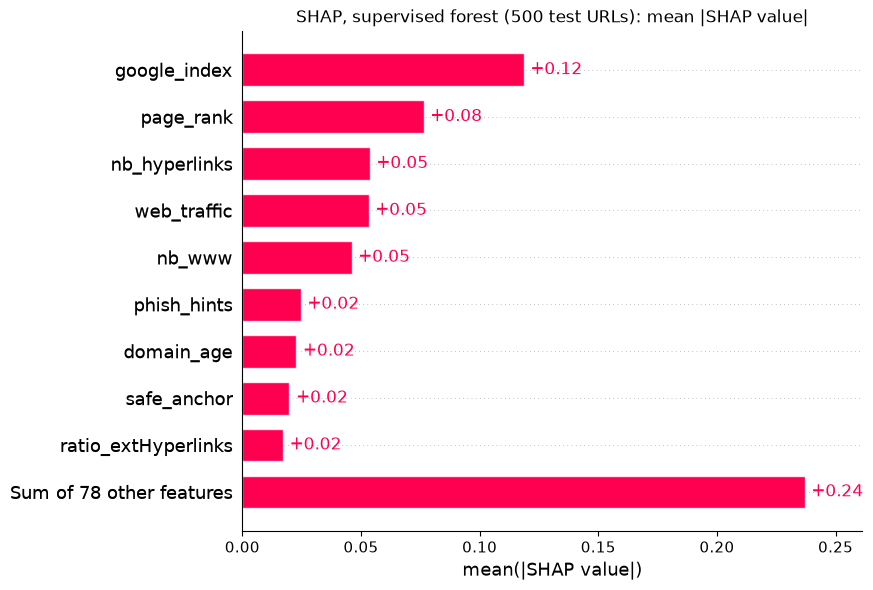

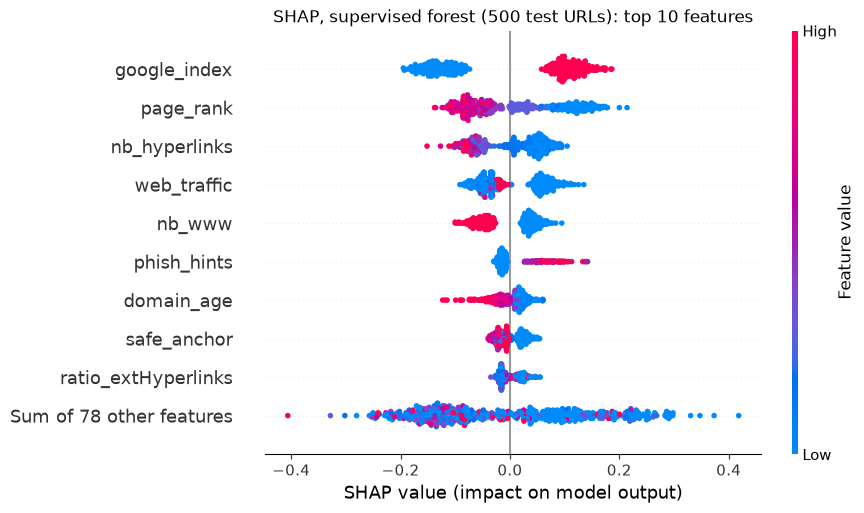

google_index            0.1186
page_rank               0.0764
nb_hyperlinks           0.0537
web_traffic             0.0532
nb_www                  0.0460
phish_hints             0.0246
domain_age              0.0227
safe_anchor             0.0199
ratio_extHyperlinks     0.0171
ratio_extRedirection    0.0142
dtype: float64


In [13]:
# STEP B2
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)
sv = explainer(X_test.iloc[:500])         # 500 test URLs is plenty
print(sv.values.shape)                    # (500, 87, 2) = URLs, features, classes
assert sv.values.shape == (500, 87, 2)
sv1 = sv[:, :, 1]                         # keep class 1 = phishing

shap.plots.bar(sv1, max_display=10, show=False)        # average push of each feature
plt.title("SHAP, supervised forest (500 test URLs): mean |SHAP value|")
plt.savefig("results/figures/B2_shap_forest_bar.png", dpi=150, bbox_inches="tight")
plt.show()
shap.plots.beeswarm(sv1, max_display=10, show=False)   # one dot per URL
plt.title("SHAP, supervised forest (500 test URLs): top 10 features")
plt.savefig("results/figures/B2_shap_forest_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

shap_top = pd.Series(np.abs(sv1.values).mean(axis=0),
                     index=X_test.columns).sort_values(ascending=False)
print(shap_top.head(10).round(4))
shap_top.rename("mean_abs_shap").rename_axis("feature").to_csv("results/tables/B2_shap_top.csv")

<!-- STEP B2 -->
**What we see**

- **The top feature is `google_index`, and its red dots are on the right.** Red = high value = 1 =
  Google has **not** indexed the page, and right = toward phishing. In plain words: "not indexed by
  Google" is the forest's strongest single reason to call a URL phishing, and "indexed" (blue, left)
  its strongest reason to call it legitimate.
- The next features read the same way: a **low** `page_rank` (blue) and **few** links (`nb_hyperlinks`,
  blue) push toward phishing, and a **low** `web_traffic` pushes toward phishing too, because 0 means
  "no traffic rank found" (81% of those URLs are phishing). More phishing words (`phish_hints`, red)
  push toward phishing; a young domain (`domain_age`, blue) slightly so.
- Three of the top four features (`google_index`, `page_rank`, `web_traffic`) are **external lookups**.
  Step C1 tests what happens without them.

<!-- STEP B3 -->
## Step B3: SHAP for the semi- and self-supervised models

The semi-supervised model is a forest, so `TreeExplainer` works (exact and fast), on the same 500 test
URLs as the supervised forest in step B2. The self-supervised model is not a tree, so we use the
general `shap.Explainer` with 100 ordinary training URLs as the background, on 200 URLs (it is
slower).

(500, 87) (200, 87)


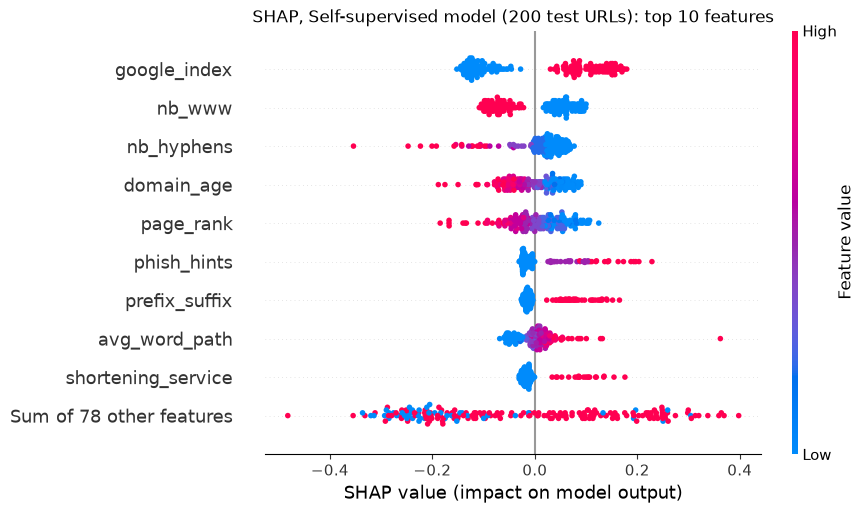

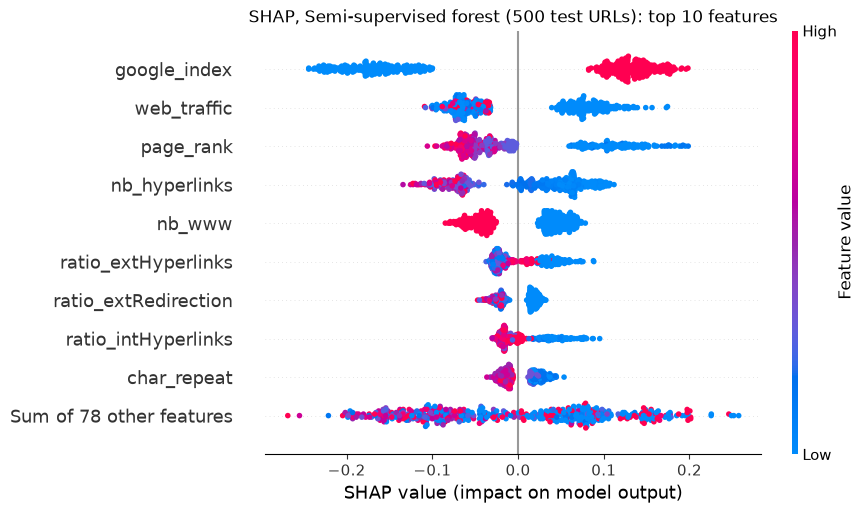

In [14]:
# STEP B3
import shap
import matplotlib.pyplot as plt

# Semi-supervised model: also a forest, so TreeExplainer works
sv_semi = shap.TreeExplainer(rf_semi)(X_test.iloc[:500])[:, :, 1]

# Self-supervised model: not a tree, so we use the general explainer.
# It works for any model but is slower, so we explain only 200 URLs.
def self_prob(a):
    a = pd.DataFrame(a, columns=X_train.columns)
    return self_sup.predict_proba(a)[:, 1]

background = X_train.sample(100, random_state=42)   # "ordinary" URLs
explainer_self = shap.Explainer(self_prob, background, seed=42)   # seed: its permutations are random
sv_self = explainer_self(X_test.iloc[:200], silent=True)   # silent: no progress bar
print(sv_semi.values.shape, sv_self.values.shape)    # (500, 87) (200, 87)
assert sv_semi.values.shape == (500, 87) and sv_self.values.shape == (200, 87)

for sv_model, name, title in [(sv_self, "self", "Self-supervised model (200 test URLs)"),
                              (sv_semi, "semi", "Semi-supervised forest (500 test URLs)")]:
    shap.plots.beeswarm(sv_model, max_display=10, show=False)
    plt.title(f"SHAP, {title}: top 10 features")
    plt.savefig(f"results/figures/B3_shap_{name}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()

<!-- STEP B4 -->
## Step B4: Do the models look at the same clues?

The top 10 features of each model, side by side: the two glass boxes read directly (tree importance,
absolute logistic-regression weight) and the three SHAP rankings (mean absolute SHAP value).

In [15]:
# STEP B4
def top10(sv):
    s = pd.Series(np.abs(sv.values).mean(axis=0), index=X_test.columns)
    return s.sort_values(ascending=False).index[:10]

tree_top = pd.Series(tree.feature_importances_, index=X_train.columns)

lists = pd.DataFrame({
    "tree":        tree_top.sort_values(ascending=False).index[:10],
    "logreg":      w.abs().sort_values(ascending=False).index[:10],
    "SHAP forest": top10(sv1),
    "SHAP semi":   top10(sv_semi),
    "SHAP self":   top10(sv_self),
})
lists.index = range(1, 11)
lists.index.name = "rank"
print(lists.to_string())
lists.to_csv("results/tables/B4_top10_lists.csv")

# In how many of the 5 lists does each feature appear?
counts = pd.Series(lists.values.ravel()).value_counts()
print("\nfeatures in 3 or more lists:")
print(counts[counts >= 3].to_string())

# Does the self-supervised model look at other clues than the two forests?
forests = set(lists["SHAP forest"]) | set(lists["SHAP semi"])
print("\nshared top-10 features: forest & semi =",
      len(set(lists["SHAP forest"]) & set(lists["SHAP semi"])),
      "| self & forest =", len(set(lists["SHAP self"]) & set(lists["SHAP forest"])),
      "| self & semi =", len(set(lists["SHAP self"]) & set(lists["SHAP semi"])))
print("only in the self-supervised top 10:", sorted(set(lists["SHAP self"]) - forests))

                      tree             logreg           SHAP forest             SHAP semi           SHAP self
rank                                                                                                         
1             google_index  longest_words_raw          google_index          google_index        google_index
2                page_rank          page_rank             page_rank           web_traffic              nb_www
3            nb_hyperlinks        phish_hints         nb_hyperlinks             page_rank          nb_hyphens
4                   nb_www       google_index           web_traffic         nb_hyperlinks          domain_age
5                    nb_qm      avg_word_host                nb_www                nb_www           page_rank
6              web_traffic         nb_hyphens           phish_hints   ratio_extHyperlinks         phish_hints
7              phish_hints             nb_www            domain_age  ratio_extRedirection       prefix_suffix
8       sh

<!-- STEP B4 -->
**What we see**

- **In every one of the 5 lists:** `google_index`, `page_rank` and `nb_www`. **In 4 of 5:**
  `nb_hyperlinks` and `phish_hints`. So whichever way a model is built or explained, it leans on whether
  Google indexes the page, how well-linked the site is, how often "www" appears, how many links the page
  has and how many phishing words are in the URL. Two of these (`google_index`, `page_rank`) are
  external lookups, which step C1 removes.
- **The two forests look at almost the same clues** (8 of 10 shared). That is expected: the
  semi-supervised forest learned from pseudo-labels that a forest produced.
- **The self-supervised model partly looks elsewhere:** it shares only 5 features with the supervised
  forest and 3 with the semi-supervised one. Five of its top 10 appear in no forest list:
  `nb_hyphens`, `prefix_suffix`, `shortening_service`, `avg_word_path`, `domain_in_title`, almost all
  taken from the URL text. It still agrees on the strongest clue: `google_index` is first in both
  SHAP forest lists and in its own.
- **One surprise in its beeswarm (figure `B3_shap_self_beeswarm.png`):** many hyphens push toward
  *legitimate*, although hyphens are usually a phishing sign. A linear model on 32 learned numbers can
  pick up such indirect patterns; it is a reason not to trust this model's explanation blindly.
- **The logistic regression is the odd one out** among the supervised models: its top weight is
  `longest_words_raw`, and its list is mostly URL-text features, because a weight reflects one feature
  with the others held fixed, not how much the feature matters on its own.